##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
import re
import spacy
import nltk
from nltk.corpus import stopwords
import plotly.express as px

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##### Load the dataset

In [2]:
df_clean = pd.read_csv(r'C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Customer Feedback Analysis\Data\cleaned_reviews.csv')


##### Exploratory Data Analysis

- Univarate analysis (numerical columns)

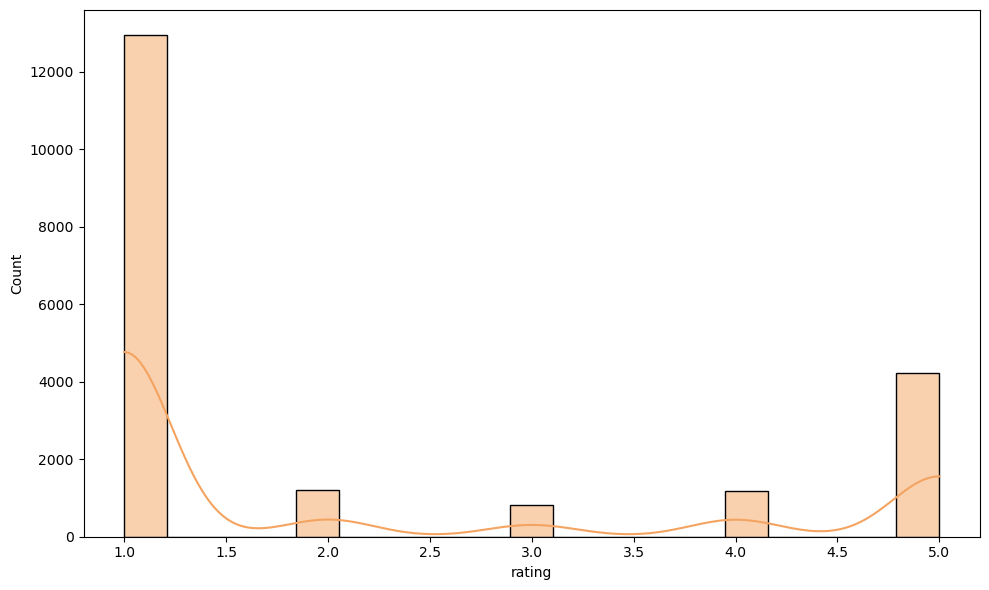

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["rating"], kde=True, color="sandybrown") 
plt.tight_layout()
plt.show()


     Most reviews are either 1 star or 5 stars. Very few people give 2, 3, or 4 stars.

- Univarate analysis (other columns)

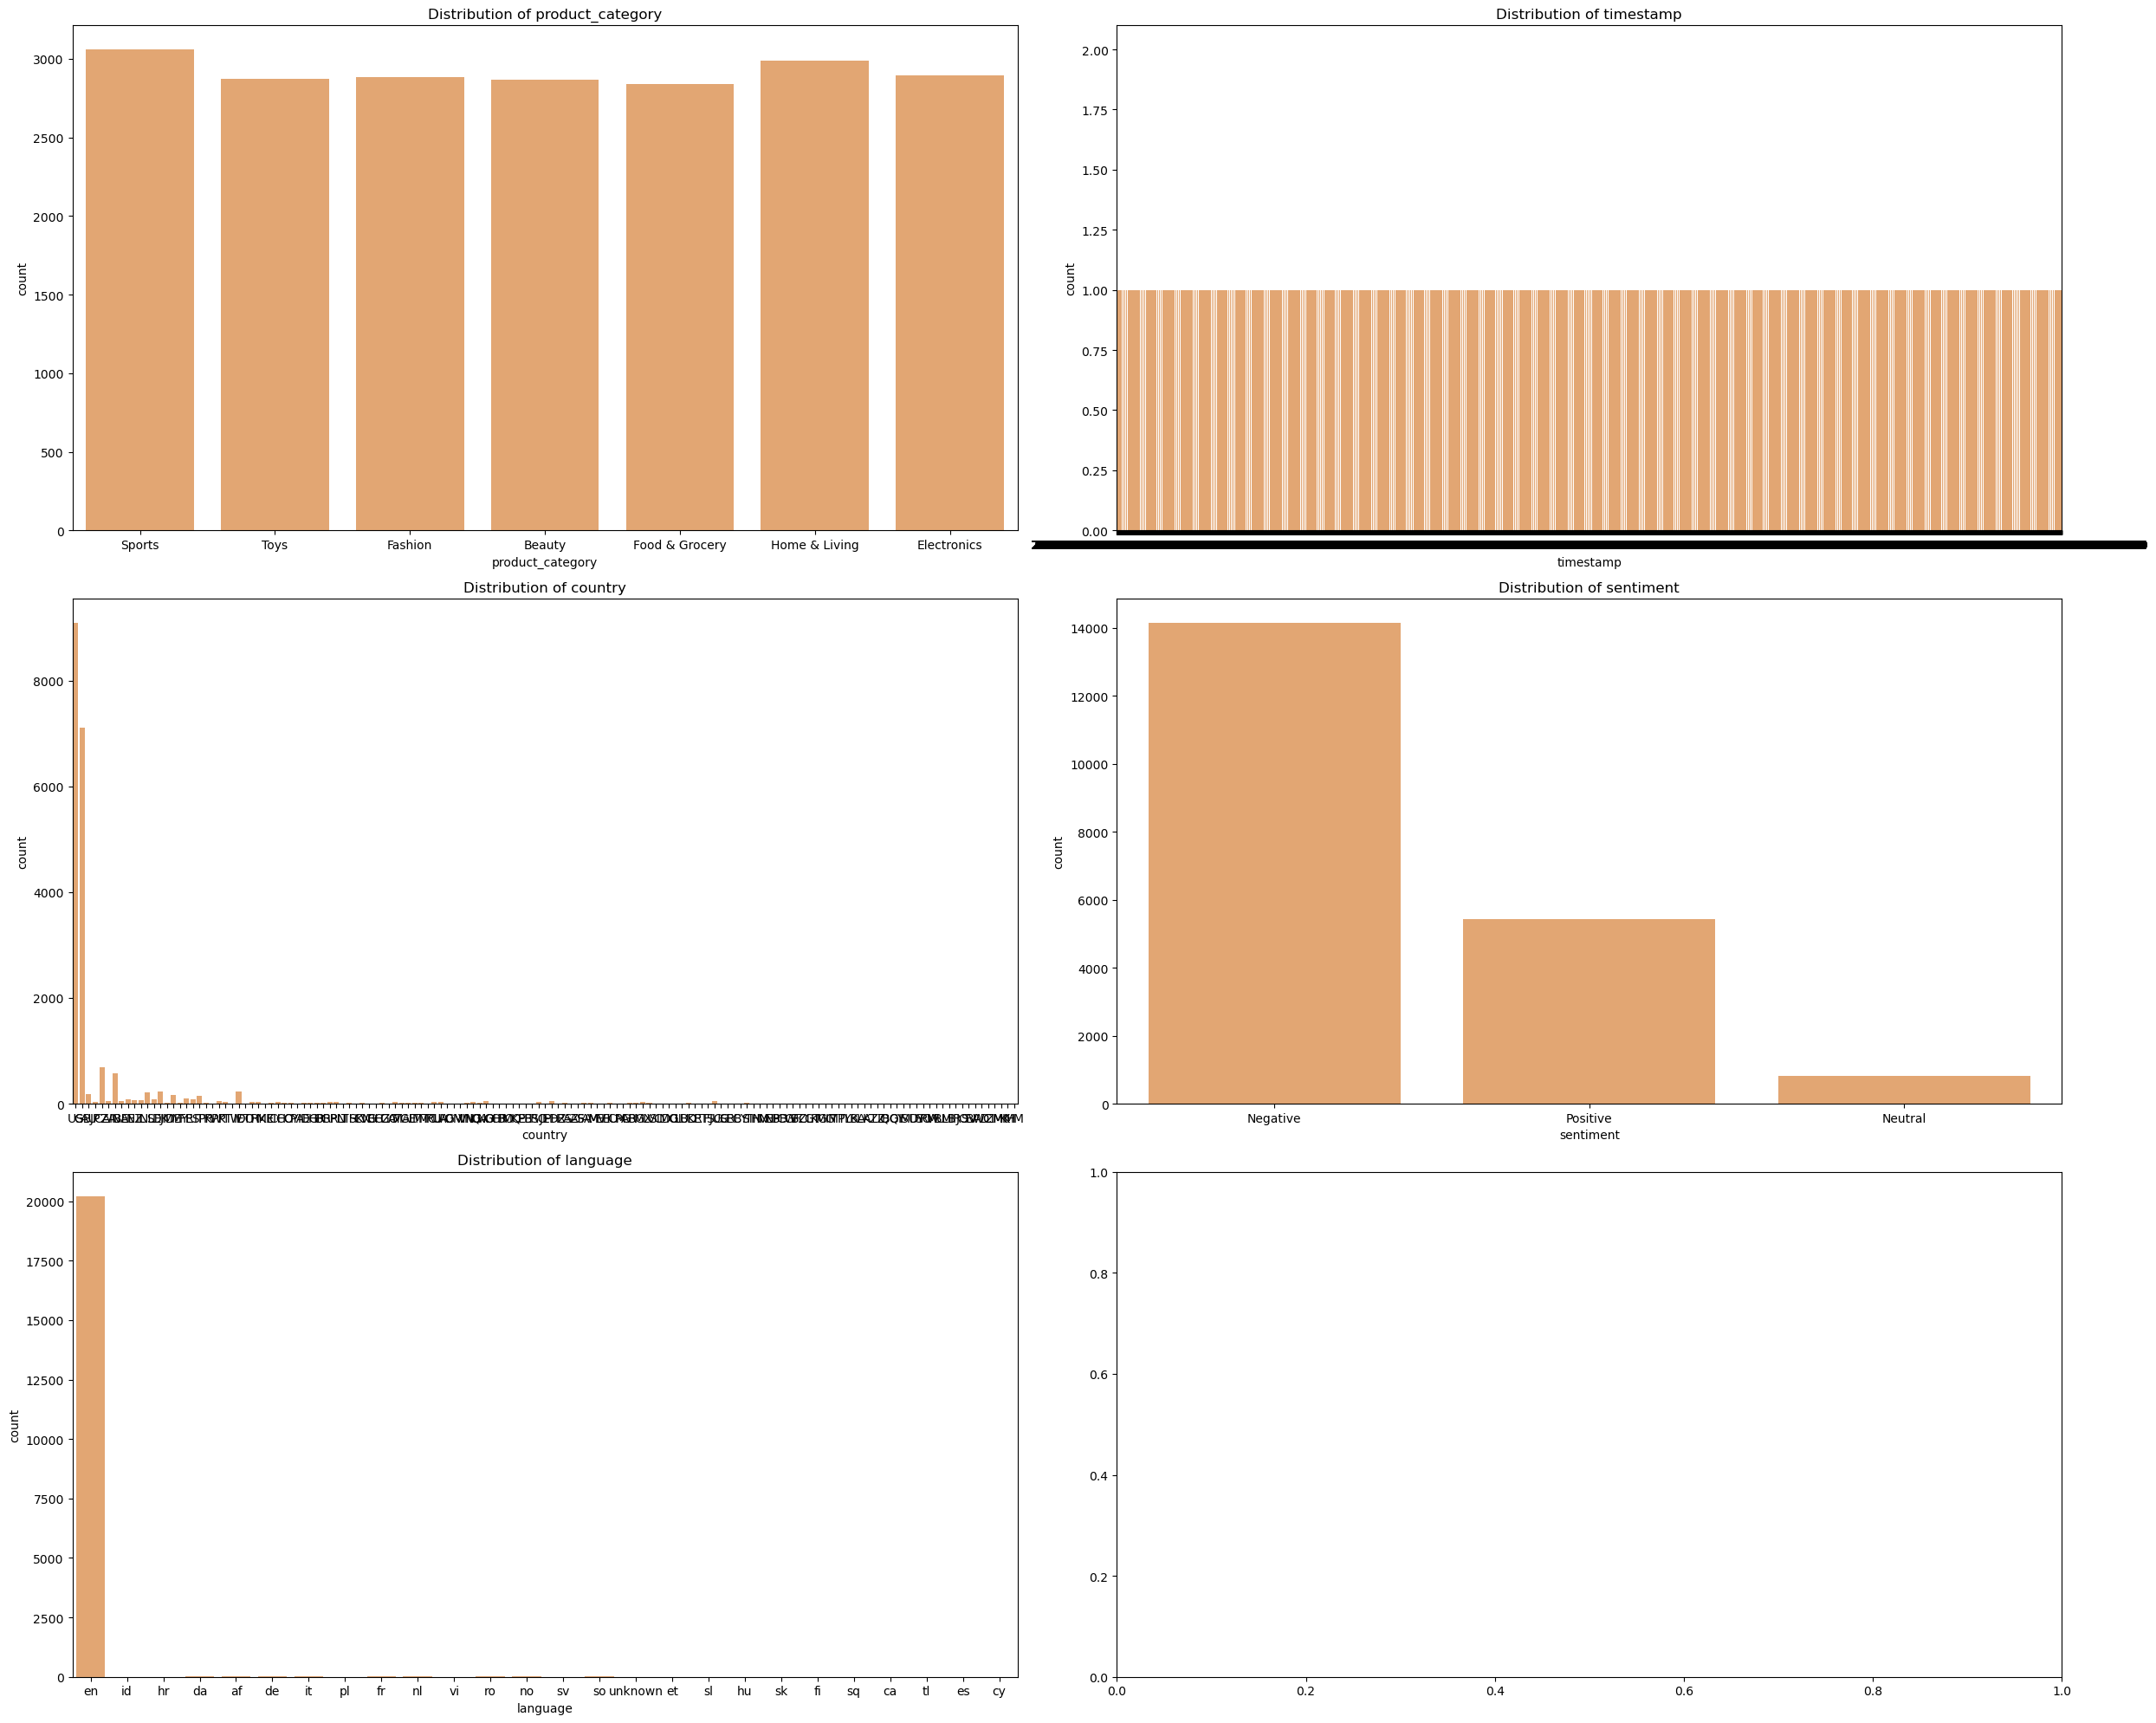

In [4]:
categorical_cols = df_clean.select_dtypes(include="object").columns.drop(["review", "review_id", "processed_review"])

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(25,20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_clean, x=col, ax=axes[i], color="sandybrown")
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

     All product types have almost equal number of reviews. Most reviews are negative. Almost all reviews are in English. Other languages are very small in number. Negative reviews are the majority (14,000+).

- Analyze sentiment balance

In [5]:
sentiment_counts = df_clean["sentiment"].value_counts(normalize=True) * 100
sentiment_counts

sentiment
Negative    69.375153
Positive    26.581720
Neutral      4.043127
Name: proportion, dtype: float64

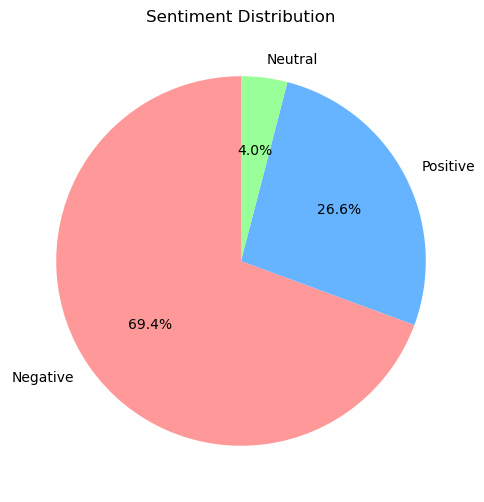

In [6]:
plt.figure(figsize=(8,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=["#ff9999","#66b3ff","#99ff99"])
plt.title("Sentiment Distribution")
plt.show()

       Nearly 70% of the reviews are negative, while only 4% is Neutral. This shows it is heavily unblanced.

- Sentiment distribution by category

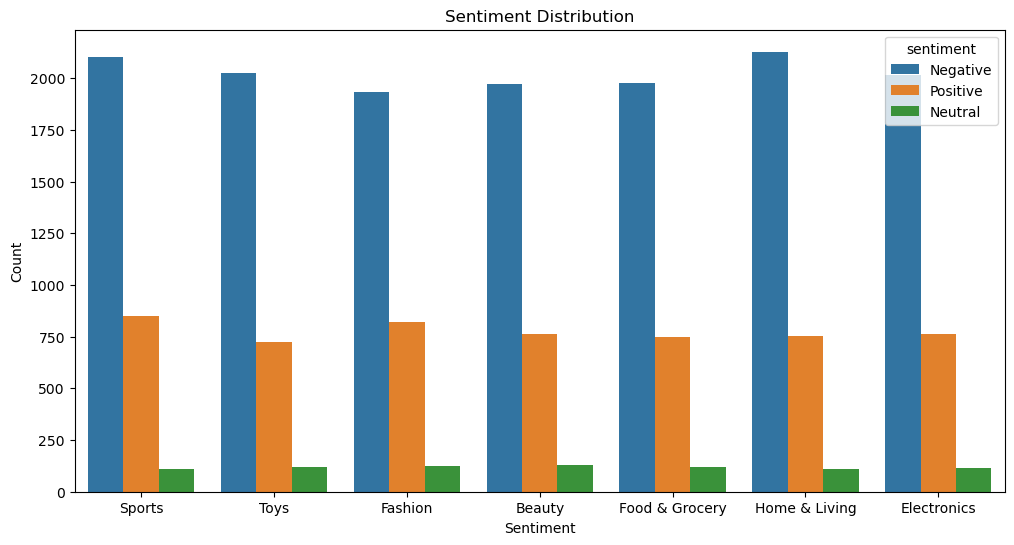

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, hue ="sentiment", x="product_category")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

      All product categories show the same sentiment pattern. Most reviews are negative across every category. Positive reviews are fewer, and neutral reviews are very rare.
      Electronics, sports and Home & Living have the highest negative reviews, Fashion has slightly fewer negative reviews. Sports and Fashion have the most positive reviews.
      Toys has the lowest number of positive reviews.

- Sentiment Distribution by Country

In [8]:
country_sentiment = (df_clean.groupby("country")["sentiment"].value_counts().unstack().fillna(0))
country_sentiment.head()

sentiment,Negative,Neutral,Positive
country,,,
AD,0.0,0.0,2.0
AE,62.0,1.0,19.0
AF,1.0,0.0,0.0
AG,1.0,0.0,0.0
AM,7.0,0.0,2.0


In [9]:
country_sentiment_pct = round(df_clean.groupby("country")["sentiment"].value_counts(normalize=True).unstack().fillna(0) * 100, 2)
country_sentiment_pct

sentiment,Negative,Neutral,Positive
country,,,
AD,0.00,0.00,100.00
AE,75.61,1.22,23.17
AF,100.00,0.00,0.00
AG,100.00,0.00,0.00
AM,77.78,0.00,22.22
...,...,...,...
VG,0.00,100.00,0.00
VI,100.00,0.00,0.00
VN,56.25,6.25,37.50


- Countries with the highest positive sentiment.

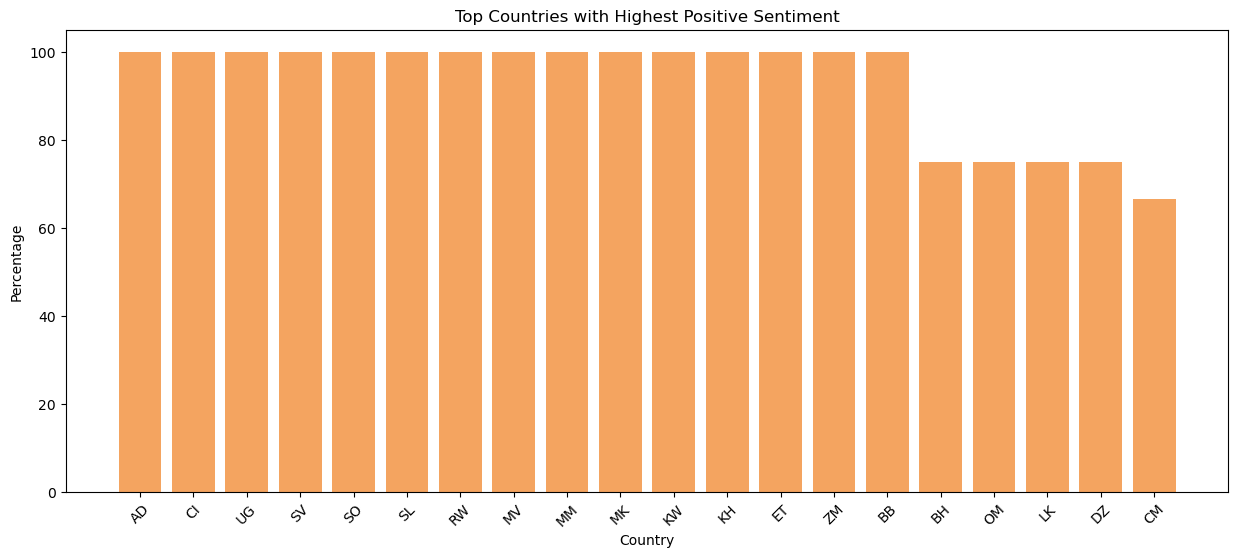

In [10]:
top_positive_country = country_sentiment_pct.sort_values( by="Positive", ascending=False).head(20)

plt.figure(figsize=(15,6))
plt.bar(top_positive_country.index, top_positive_country["Positive"], color="sandybrown")
plt.title("Top Countries with Highest Positive Sentiment")
plt.xlabel("Country")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()



      Andorra, Ivory Coast, Uganda and El Salvador are amongst the countries with highest positive with 100%.

- Countries with the highest negaitive sentiment.

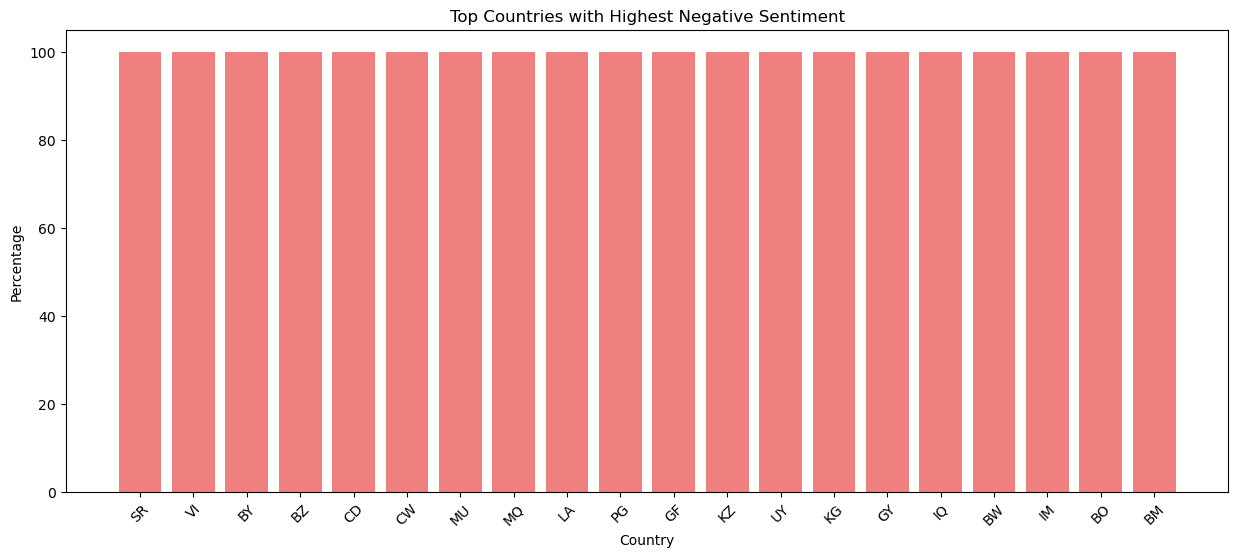

In [11]:
top_negative_country = country_sentiment_pct.sort_values( by="Negative", ascending=False).head(20)

plt.figure(figsize=(15,6))
plt.bar(top_negative_country.index, top_negative_country["Negative"], color="lightcoral")
plt.title("Top Countries with Highest Negative Sentiment")
plt.xlabel("Country")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


     Suriname, U.S. Virgin Islands, Belarus and Belize are amongst the countries with 100% negative reviews.

In [12]:
fig = px.bar(country_sentiment_pct.reset_index(), x="country", y=["Positive", "Neutral", "Negative"], title="Sentiment Distribution by Country (%)", barmode="stack")

fig.update_layout(xaxis_tickangle=-90, height=700)

fig.show()

     Negative sentiment is the largest part in almost every country. A few countries show a good amount of positive feedback. But many countries have no positive reviews at all. Neutral reviews are very small everywhere. Some countries look extreme (100% positive or 100% negative), this happens because those countries have very few reviews.
     

- Rating vs Sentiment

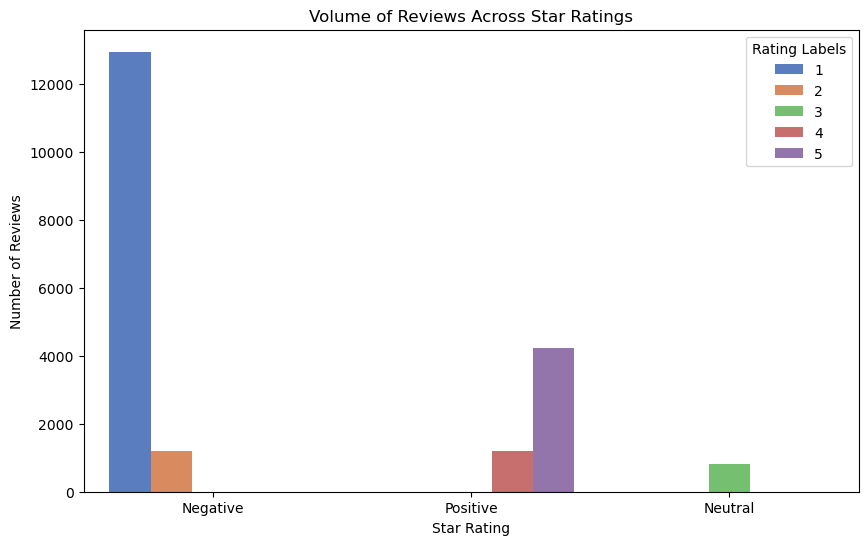

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, hue="rating", x="sentiment", palette="muted")
plt.title("Volume of Reviews Across Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.legend(title="Rating Labels")
plt.show()

     Negative sentiment - almost all reviews are 1 star (around 13,000), with a small number of 2-star ratings. This shows unhappy customers usually give the lowest score.
     Positive sentiment - most reviews are 5 stars (about 4,200), with fewer 4-star ratings. This shows satisfied customers mostly give perfect scores.
     Neutral sentimentB- only 3-star reviews appear, and they are very few (under 1,000). This shows customers rarely leave middle-ground ratings.

- Language by Sentiment Breakdown

In [14]:
fig = px.histogram(df_clean, x="language", color="sentiment", barmode="group", title="Language by Sentiment Breakdown")
fig.show()

     English dominates almost the entire dataset, with over 14,000 negative reviews, around 5,000 positive reviews, and fewer than 1,000 neutral reviews. This means most of the feedback is written in English and is mostly negative overall.
     All other languages (such as German, French, Spanish, and many more) have very small counts, almost invisible on the chart. This shows they make up a tiny fraction of the dataset.